In [1]:
import nest_asyncio
nest_asyncio.apply()  # Cho phép nest event loop trong Jupyter

import sys
sys.path.insert(0, "/home/duoc/workflow/api")  # thư mục chứa folder app/
print("Cấu hình sys.path thành công! Thư mục hiện tại:")

Cấu hình sys.path thành công! Thư mục hiện tại:


2026-06-15 13:30:46,510 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-15 13:30:46,511 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("conversation")
2026-06-15 13:30:46,512 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-06-15 13:30:46,513 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("message")
2026-06-15 13:30:46,514 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-06-15 13:30:46,516 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("businesses")
2026-06-15 13:30:46,516 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-06-15 13:30:46,517 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("knowledge_document_source")
2026-06-15 13:30:46,518 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-06-15 13:30:46,520 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("knowledge_document_page")
2026-06-15 13:30:46,520 INFO sqlalchemy.engine.Engine [raw sql] ()
2026-06-15 13:30:46,522 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("knowledge_image_source")
2026-06-1

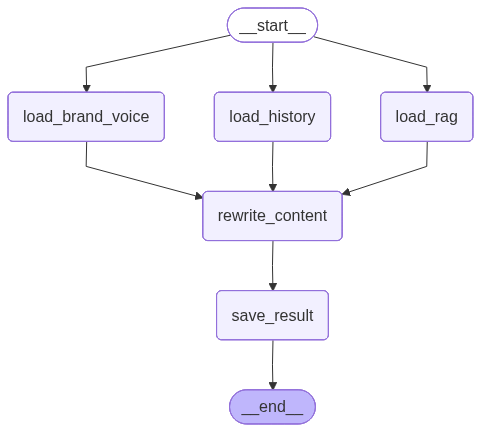

In [2]:
from __future__ import annotations
from typing import Annotated, Any, Optional, TypedDict
import operator
import uuid
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from app.chat.workflow import chat_graph
from app.db import init_db, AsyncSessionLocal
from app.chat.models import Conversation, Message


# ── Seed dữ liệu test (Conversation + Message thật) ────────
async def seed_test_data():
    async with AsyncSessionLocal() as db:
        conv = Conversation(title="Test conversation")
        db.add(conv)
        await db.flush()  # để có conv.id trước khi commit

        msg = Message(
            conversation_id=conv.id,
            role="assistant",
            content="",
            status="pending",
        )
        db.add(msg)
        await db.commit()

        print(f"🆔 conversation_id = {conv.id}")
        print(f"🆔 msg_id          = {msg.id}")
        return conv.id, msg.id


# ── KHỞI CHẠY HỆ THỐNG ────────────────────────────────────
async def run_workflow():
    # Đảm bảo toàn bộ model SQLAlchemy được import/đăng ký
    # trước khi graph chạy các node truy vấn DB (load_brand_voice, load_rag, save_result)
    await init_db()

    # Tạo Conversation + Message thật trong DB để save_result có thể update
    conv_id, msg_id = await seed_test_data()

    # Khai báo Input map chuẩn xác, khít 100% với các trường trong EditorState
    inputs = {
        "session_id": "blog_gen_001",
        "conversation_id": str(conv_id),
        "msg_id": str(msg_id),
        "instruction": "Viết bài viết giới thiệu về dịch vụ buffet sáng của khách sạn biển nongnghiepho2",
        "brand_id": "nongnghiepho2",
        "business_id": "biz_nongnghiep_001",
        "content_draft": "",
        "knowledge_rag": [],
        "error": None,
    }

    # Thực hiện gọi bất đồng bộ
    result = await chat_graph.ainvoke(
        inputs,
        config={"configurable": {"thread_id": "content_generation_thread"}}
    )

    print("\n====== KẾT QUẢ XỬ LÝ ======")
    if result.get("error"):
        print(f"❌ Thất bại: {result.get('error')}")
    else:
        print(f"✅ Saved DB status: {result.get('saved')}")
        print(f"📝 Nội dung hoàn thiện:\n{result.get('rewritten_text')}")


await run_workflow()

# ── Vẽ graph để kiểm tra cấu trúc ──────────────────────────
img_bytes = chat_graph.get_graph(xray=True).draw_mermaid_png()
from IPython.display import Image, display
display(Image(data=img_bytes))